# Costs and Trend-Following Comparison

This notebook adds the missing extensions to the original SPY buy-the-dip analysis without changing `01_data_baseline.ipynb`.

It reuses the same basic SPY setup, then adds cash returns, transaction costs, a 10-month moving-average trend-following rule, a 12-month time-series momentum rule, and one final comparison table.

## Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## SPY and Cash Data

The original notebook uses SPY from Yahoo Finance, so this notebook keeps the same data source. I use `^IRX` as a simple cash proxy and convert the quoted annual yield into an approximate daily cash return.

In [2]:
spy = yf.download("SPY", start="1993-01-01", auto_adjust=True, progress=False)

prices = spy["Close"].squeeze()
daily_returns = prices.pct_change().fillna(0)

irx = yf.download("^IRX", start=prices.index.min(), auto_adjust=False, progress=False)
cash_yield = irx["Close"].squeeze().reindex(prices.index).ffill().fillna(0)
cash_returns = (cash_yield / 100) / 252

print(f"sample start: {prices.index.min().date()}")
print(f"sample end:   {prices.index.max().date()}")
prices.tail()

sample start: 1993-01-29
sample end:   2026-07-09


Date
2026-07-02    744.780029
2026-07-06    751.280029
2026-07-07    747.710022
2026-07-08    745.400024
2026-07-09    751.710022
Name: SPY, dtype: float64

## Cost Assumption

The transaction cost is deliberately simple: every one-way change in exposure costs 5 basis points. Moving from 0% invested to 100% invested costs 5 bps, and moving back to cash costs another 5 bps.

In [3]:
transaction_cost = 0.0005

transaction_cost

0.0005

## Shared Backtest Helpers

These helper functions keep the comparison consistent across buy-and-hold, buy-the-dip, and trend-following strategies.

In [4]:
def apply_execution_model(position, risky_returns, cash_returns, transaction_cost=0.0):
    position = position.reindex(risky_returns.index).ffill().fillna(0)
    cash_returns = cash_returns.reindex(risky_returns.index).ffill().fillna(0)

    # turnover is the daily change in market exposure
    turnover = position.diff().abs().fillna(0)
    gross_returns = position * risky_returns + (1 - position) * cash_returns
    net_returns = gross_returns - turnover * transaction_cost
    equity = (1 + net_returns).cumprod()

    return net_returns, equity, position, turnover


def compute_stats(returns, equity):
    years = len(returns) / 252
    drawdown = equity / equity.cummax() - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = np.nan if returns.std() == 0 else returns.mean() / returns.std() * np.sqrt(252)

    return pd.Series({
        "CAGR": equity.iloc[-1] ** (1 / years) - 1,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": drawdown.min(),
    })


def compute_regression_stats(returns, position, turnover):
    data = pd.DataFrame({
        "Strategy": returns,
        "SPY": daily_returns,
    }).dropna()

    beta = data["Strategy"].cov(data["SPY"]) / data["SPY"].var()
    daily_alpha = data["Strategy"].mean() - beta * data["SPY"].mean()
    corr = data["Strategy"].corr(data["SPY"])
    years = len(returns) / 252

    return pd.Series({
        "Beta": beta,
        "Annual Alpha": daily_alpha * 252,
        "Correlation": corr,
        "R Squared": corr ** 2,
        "Average Exposure": position.mean(),
        "Annual Turnover": turnover.sum() / years,
    })


def summarize_strategy(name, returns, equity, position, turnover):
    row = pd.concat([
        compute_stats(returns, equity),
        compute_regression_stats(returns, position, turnover),
    ])
    row["Strategy"] = name
    return row

## Buy-and-Hold Benchmark

Buy-and-hold is 100% invested in SPY every day. I do not charge a transaction cost here because the notebook starts after the initial position is already established.

In [5]:
buy_hold_position = pd.Series(1.0, index=prices.index)
buy_hold_returns, buy_hold_equity, buy_hold_position, buy_hold_turnover = apply_execution_model(
    buy_hold_position,
    daily_returns,
    cash_returns,
    transaction_cost=0.0,
)

## Buy-the-Dip Strategies After Costs

This recreates the original buy-the-dip grid, but now uninvested capital earns the cash return and position changes pay transaction costs.

In [6]:
def run_btd_strategy(depth, lookback, hold):
    rolling_peak = prices.rolling(lookback).max()
    rolling_drawdown = prices / rolling_peak - 1
    buy_signal = rolling_drawdown <= depth

    position = buy_signal.rolling(hold).max().fillna(0)

    # shift so today's close cannot trigger today's trade
    position = position.shift(1).fillna(0)

    return apply_execution_model(position, daily_returns, cash_returns, transaction_cost)

In [7]:
depths = [-0.05, -0.10, -0.15, -0.20]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

holds = {
    "1M": 21,
    "2M": 42,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
    "3Y": 756,
    "5Y": 1260,
}

btd_returns = {}
btd_equity = {}
btd_positions = {}
btd_turnover = {}
rows = []

for depth in depths:
    for lookback_name, lookback in lookbacks.items():
        for hold_name, hold in holds.items():
            name = f"{int(abs(depth) * 100)}% depth, {lookback_name} lookback, {hold_name} hold"
            returns, equity, position, turnover = run_btd_strategy(depth, lookback, hold)

            btd_returns[name] = returns
            btd_equity[name] = equity
            btd_positions[name] = position
            btd_turnover[name] = turnover

            row = summarize_strategy(name, returns, equity, position, turnover)
            row["Depth"] = depth
            row["Lookback"] = lookback_name
            row["Hold"] = hold_name
            rows.append(row)

btd_results = pd.DataFrame(rows)

best_btd_cagr = btd_results.loc[btd_results["CAGR"].idxmax(), "Strategy"]

# avoid calling a basically-cash strategy the best sharpe strategy
investable_btd = btd_results[btd_results["Average Exposure"] >= 0.25]
best_btd_sharpe = investable_btd.loc[investable_btd["Sharpe Ratio"].idxmax(), "Strategy"]

btd_results.sort_values("CAGR", ascending=False).head(10)

,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta,Annual Alpha,Correlation,R Squared,Average Exposure,Annual Turnover,Strategy,Depth,Lookback,Hold
31,0.110482,0.179974,0.672399,-0.551895,0.939329,0.008062,0.969163,0.939277,0.830937,1.047879,"5% depth, 3M lookback, 6M hold",-0.05,3M,6M
24,0.108488,0.178556,0.666245,-0.551895,0.924614,0.007779,0.961556,0.924590,0.787335,1.107758,"5% depth, 1M lookback, 6M hold",-0.05,1M,6M
45,0.107892,0.180371,0.658368,-0.551895,0.943459,0.005301,0.971285,0.943394,0.838422,0.868243,"5% depth, 1Y lookback, 6M hold",-0.05,1Y,6M
38,0.107117,0.180246,0.654813,-0.551895,0.942146,0.004736,0.970603,0.942069,0.834620,0.868243,"5% depth, 6M lookback, 6M hold",-0.05,6M,6M
46,0.104820,0.183581,0.634919,-0.551895,0.977356,-0.000967,0.988589,0.977308,0.928953,0.149697,"5% depth, 1Y lookback, 1Y hold",-0.05,1Y,1Y
39,0.104820,0.183581,0.634919,-0.551895,0.977356,-0.000967,0.988589,0.977308,0.928953,0.149697,"5% depth, 6M lookback, 1Y hold",-0.05,6M,1Y
32,0.104820,0.183581,0.634919,-0.551895,0.977356,-0.000967,0.988589,0.977308,0.928953,0.149697,"5% depth, 3M lookback, 1Y hold",-0.05,3M,1Y
25,0.104389,0.182855,0.634577,-0.551895,0.969656,-0.000564,0.984691,0.969616,0.902697,0.209576,"5% depth, 1M lookback, 1Y hold",-0.05,1M,1Y
55,0.104235,0.172079,0.662312,-0.475159,0.858780,0.010703,0.926708,0.858787,0.813473,0.149697,"10% depth, 1W lookback, 5Y hold",-0.10,1W,5Y
44,0.103615,0.173361,0.655497,-0.551895,0.871496,0.008841,0.933476,0.871378,0.673161,1.916122,"5% depth, 1Y lookback, 3M hold",-0.05,1Y,3M


## Trend-Following Benchmarks

These rules are formed with month-end data and then shifted forward, so the strategy trades using information that would have been known at the time.

In [8]:
monthly_prices = prices.resample("ME").last()


def monthly_to_daily(monthly_position):
    return monthly_position.reindex(prices.index, method="ffill").fillna(0)


# 10-month moving-average rule
ten_month_ma = monthly_prices.rolling(10).mean()
ma_monthly_position = (monthly_prices > ten_month_ma).astype(float).shift(1).fillna(0)
ma_position = monthly_to_daily(ma_monthly_position)
ma_returns, ma_equity, ma_position, ma_turnover = apply_execution_model(
    ma_position,
    daily_returns,
    cash_returns,
    transaction_cost,
)


# 12-month time-series momentum rule
twelve_month_return = monthly_prices.pct_change(12)
tsmom_monthly_position = (twelve_month_return > 0).astype(float).shift(1).fillna(0)
tsmom_position = monthly_to_daily(tsmom_monthly_position)
tsmom_returns, tsmom_equity, tsmom_position, tsmom_turnover = apply_execution_model(
    tsmom_position,
    daily_returns,
    cash_returns,
    transaction_cost,
)

## Final Comparison Table

This is the main table for the extension notebook: buy-and-hold, the strongest buy-the-dip variants, and the two trend-following benchmarks, all evaluated under the same cost and cash assumptions.

In [9]:
final_rows = [
    summarize_strategy("Buy and Hold", buy_hold_returns, buy_hold_equity, buy_hold_position, buy_hold_turnover),
    summarize_strategy(
        f"Best BTD by CAGR: {best_btd_cagr}",
        btd_returns[best_btd_cagr],
        btd_equity[best_btd_cagr],
        btd_positions[best_btd_cagr],
        btd_turnover[best_btd_cagr],
    ),
    summarize_strategy(
        f"Best BTD by Sharpe: {best_btd_sharpe}",
        btd_returns[best_btd_sharpe],
        btd_equity[best_btd_sharpe],
        btd_positions[best_btd_sharpe],
        btd_turnover[best_btd_sharpe],
    ),
    summarize_strategy("10-Month MA", ma_returns, ma_equity, ma_position, ma_turnover),
    summarize_strategy("12-Month TSMOM", tsmom_returns, tsmom_equity, tsmom_position, tsmom_turnover),
]

final_table = pd.DataFrame(final_rows).set_index("Strategy")

final_table[[
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Beta",
    "Annual Alpha",
    "Correlation",
    "R Squared",
    "Average Exposure",
    "Annual Turnover",
]].sort_values("Sharpe Ratio", ascending=False)

,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta,Annual Alpha,Correlation,R Squared,Average Exposure,Annual Turnover
Strategy,,,,,,,,,,
12-Month TSMOM,0.114189,0.146928,0.809693,-0.337173,0.626071,4.368261e-02,0.791239,0.626060,0.793870,0.508970
10-Month MA,0.105772,0.139682,0.789960,-0.337173,0.565716,4.231686e-02,0.752050,0.565579,0.756564,1.407152
"Best BTD by Sharpe: 20% depth, 3M lookback, 5Y hold",0.090865,0.144065,0.675659,-0.339600,0.601809,2.497183e-02,0.775695,0.601702,0.526910,0.149697
"Best BTD by CAGR: 5% depth, 3M lookback, 6M hold",0.110482,0.179974,0.672399,-0.551895,0.939329,8.061575e-03,0.969163,0.939277,0.830937,1.047879
Buy and Hold,0.108468,0.185691,0.647576,-0.551895,1.000000,-5.464379e-17,1.000000,1.000000,1.000000,0.000000


## Equity Curve Plot

This plot is just a visual check on the final table.

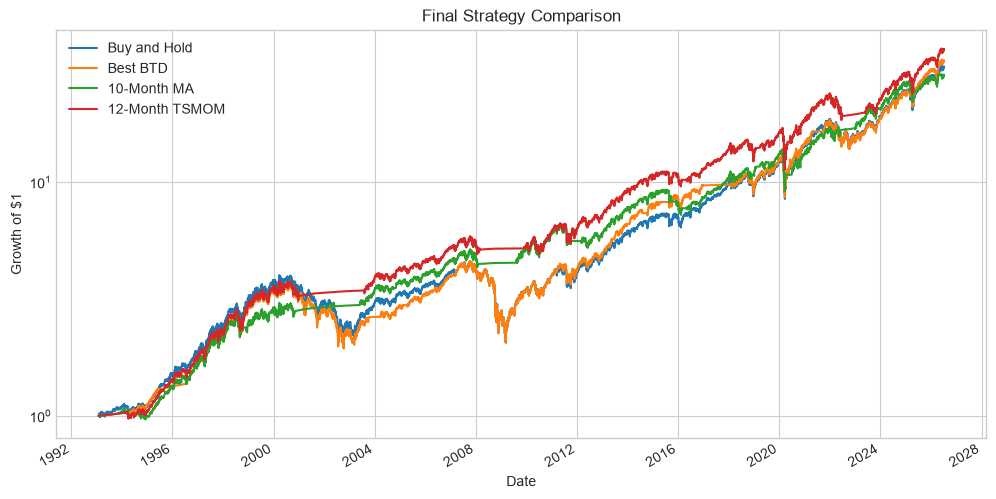

In [10]:
equity_curves = pd.DataFrame({
    "Buy and Hold": buy_hold_equity,
    "Best BTD": btd_equity[best_btd_cagr],
    "10-Month MA": ma_equity,
    "12-Month TSMOM": tsmom_equity,
})

equity_curves.plot(figsize=(12, 6), logy=True)
plt.title("Final Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()